# =====================================================
# PROYECTO FINAL
# CIENCIA DE DATOS Y MODELADO PREDICTIVO SOBRE UCI STUDENT PERFORMANCE
# =====================================================

**Sección III. Científico de Datos**  
**Autor:** Jhuomar Barría  
**Dataset analizado:** `student-mat.csv`  
**Ruta lógica del proyecto:** `projects/final_project_utp/`

## Alcance del notebook

Este cuaderno desarrolla la fase predictiva del proyecto usando **exclusivamente** el conjunto `student-mat.csv`.
El objetivo es construir, validar y comparar modelos de:

- **Clasificación**: `Random Forest` y `SVM`.
- **Regresión**: `Random Forest Regressor` y `SVR`.

La variable de clasificación se deriva de la nota final `G3` y define si un estudiante **aprueba** o **reprueba**.
La variable de regresión es la nota final `G3` directamente, lo que permite modelar el desempeño como una magnitud continua.

## Formulación del problema

Sea $G3_i$ la nota final del estudiante $i$.
Definimos la variable binaria de aprobación como:

$$
y_i = \begin{cases}
1, & \text{si } G3_i \geq 10 \\
0, & \text{si } G3_i < 10
\end{cases}
$$

La clasificación busca aproximar la función $f(\mathbf{x}) \to y$, donde $\mathbf{x}$ representa las variables personales, familiares, sociales y académicas.

Para regresión, se modela la relación:

$$
\hat{G3}_i = g(\mathbf{x})
$$

## Métricas usadas

- **Accuracy**:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- **Matriz de confusión**: resume aciertos y errores por clase.
- **Coeficiente de determinación**:

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

Un $R^2$ cercano a 1 indica que el modelo explica una fracción alta de la variabilidad observada.

## 1. Preparación del entorno y configuración reproducible

Se configura una base de trabajo reproducible con:

- búsqueda automática de la raíz del proyecto,
- control de visualización,
- funciones auxiliares para cargar datos, evaluar modelos y graficar matrices de confusión.

La lógica de rutas evita depender del directorio desde el que se abra el notebook.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, SVR

def make_one_hot_encoder():
    """Create a dense one-hot encoder that works across scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')
sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


def find_project_root() -> Path:
    """Locate the project root regardless of the current working directory."""
    cwd = Path.cwd().resolve()
    for anchor in [cwd, *cwd.parents]:
        direct = anchor / 'data' / 'raw' / 'student-mat.csv'
        if direct.exists():
            return anchor
        nested = anchor / 'projects' / 'final_project_utp' / 'data' / 'raw' / 'student-mat.csv'
        if nested.exists():
            return anchor / 'projects' / 'final_project_utp'
    raise FileNotFoundError('No se encontró la raíz del proyecto con la carpeta data/raw.')


from pathlib import Path
DATA_PATH = Path("student-mat.csv")


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ['Reprobado', 'Aprobado']
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def classification_summary(name, model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Matriz de confusión': confusion_matrix(y_test, pred),
        'Reporte': classification_report(y_test, pred, digits=4, zero_division=0),
        'Predicciones': pred,
    }


def regression_summary(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    return {
        'Modelo': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': rmse,
        'Predicciones': pred,
    }

## 2. Carga y verificación inicial del dataset

Se trabaja con `student-mat.csv`, que contiene 395 registros y 33 variables antes de cualquier ingeniería adicional.

En esta etapa se valida:

- dimensionalidad,
- tipos de datos,
- valores faltantes,
- filas duplicadas,
- una vista rápida de las primeras observaciones.

In [15]:
df = pd.read_csv(DATA_PATH, sep=';')

print('Ruta de carga:', DATA_PATH)
print('Dimensiones:', df.shape)
print('Filas duplicadas:', df.duplicated().sum())
print('Valores faltantes totales:', int(df.isna().sum().sum()))
print('\nTipos de datos:')
print(df.dtypes)

df.head()

Ruta de carga: student-mat.csv
Dimensiones: (395, 33)
Filas duplicadas: 0
Valores faltantes totales: 0

Tipos de datos:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


### Lectura técnica de la calidad de datos

Este dataset es especialmente conveniente para modelado porque:

- no presenta valores nulos,
- no requiere imputación,
- tiene mezcla de variables numéricas y categóricas,
- la variable `G3` está acotada entre 0 y 20.

Esa combinación permite diseñar pipelines de clasificación y regresión sin introducir sesgos por preprocesamientos agresivos.

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0000,NaN,NaN,NaN,16.6962,1.2760,15.0000,16.0000,17.0000,18.0000,22.0000
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0000,NaN,NaN,NaN,2.7494,1.0947,0.0000,2.0000,3.0000,4.0000,4.0000
Fedu,395.0000,NaN,NaN,NaN,2.5215,1.0882,0.0000,2.0000,2.0000,3.0000,4.0000
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Definición de la variable objetivo de clasificación

La clasificación no usa `G3` como predictor porque `G3` define el objetivo mismo.
En cambio, se construye la variable derivada `aprobado`:

- `Aprobado` si $G3 \geq 10$,
- `Reprobado` si $G3 < 10$.

Este umbral es estándar para el dataset y convierte el problema en un esquema binario claro y auditable.

aprobado
Aprobado     265
Reprobado    130
Name: count, dtype: int64

Proporción de aprobación:
aprobado
Aprobado    67.0900
Reprobado   32.9100
Name: proportion, dtype: float64


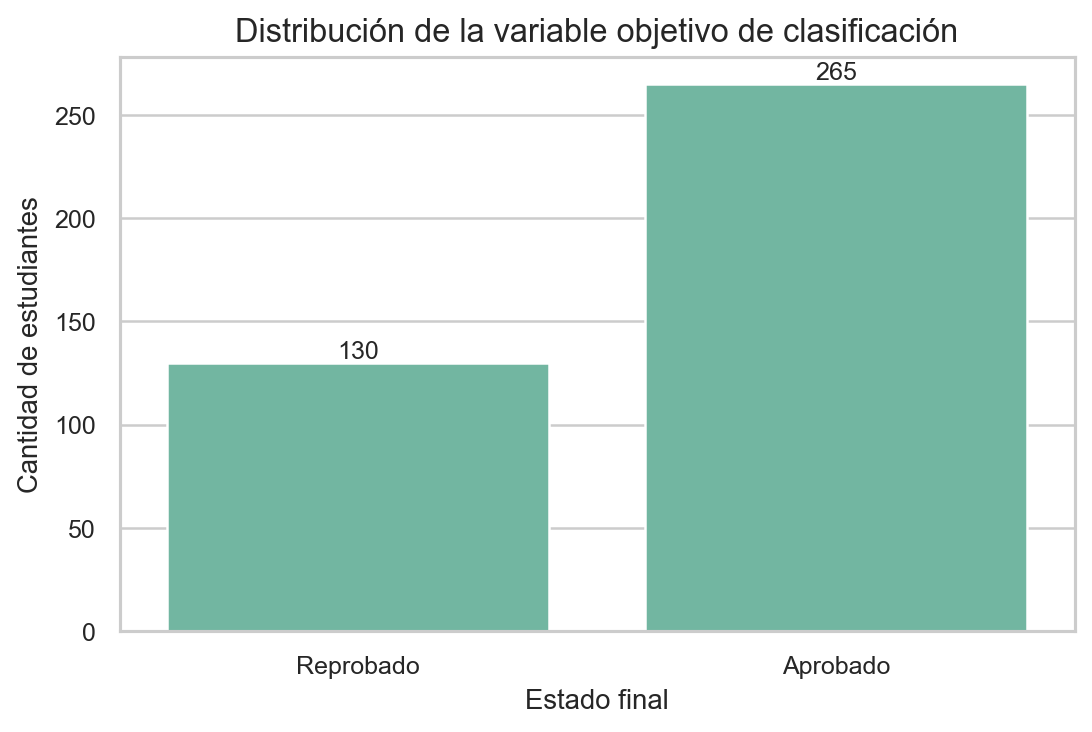

In [17]:
df['aprobado'] = np.where(df['G3'] >= 10, 'Aprobado', 'Reprobado')
df['aprobado_bin'] = (df['G3'] >= 10).astype(int)

print(df['aprobado'].value_counts())
print('\nProporción de aprobación:')
print((df['aprobado'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6.2, 4.2))
sns.countplot(data=df, x='aprobado', order=['Reprobado', 'Aprobado'])
plt.title('Distribución de la variable objetivo de clasificación')
plt.xlabel('Estado final')
plt.ylabel('Cantidad de estudiantes')
for i, v in enumerate(df['aprobado'].value_counts().reindex(['Reprobado', 'Aprobado'])):
    plt.text(i, v + 2, str(int(v)), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Diseño experimental

Se construyen dos conjuntos de modelado:

1. **Clasificación**: objetivo `aprobado`.
2. **Regresión**: objetivo numérico `G3`.

### Criterios de partición

- `train_test_split` con `test_size = 0.20`.
- `random_state = 42` para reproducibilidad.
- En clasificación se aplica `stratify` para conservar la proporción de clases.

### Variables usadas

Se emplean todas las variables explicativas disponibles, excepto la variable objetivo del caso correspondiente:

- Clasificación: se excluyen `G3`, `aprobado` y `aprobado_bin`.
- Regresión: se excluye `G3`.

Esta decisión permite aprovechar la información personal, familiar, social y académica del conjunto.

In [18]:
# Variables para clasificación
X_cls = df.drop(columns=['G3', 'aprobado', 'aprobado_bin'])
y_cls = df['aprobado_bin']

# Variables para regresión
X_reg = df.drop(columns=['G3', 'aprobado', 'aprobado_bin'])
y_reg = df['G3']

categorical_cols = X_cls.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = X_cls.select_dtypes(include=np.number).columns.tolist()

print('Variables categóricas:', len(categorical_cols))
print('Variables numéricas:', len(numeric_cols))
print('Categóricas:', categorical_cols)
print('Numéricas:', numeric_cols)

# Preprocesamiento.
# - Para modelos basados en árboles no se escala el bloque numérico.
# - Para SVM/SVR se escala el bloque numérico, porque la geometría del margen depende de la magnitud de las variables.
preprocess_tree = ColumnTransformer(
    transformers=[
        ('cat', make_one_hot_encoder(), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)

preprocess_scaled = ColumnTransformer(
    transformers=[
        ('cat', make_one_hot_encoder(), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ]
)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls,
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42,
)

print('Clasificación -> train:', X_cls_train.shape, '| test:', X_cls_test.shape)
print('Regresión     -> train:', X_reg_train.shape, '| test:', X_reg_test.shape)

Variables categóricas: 17
Variables numéricas: 15
Categóricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numéricas: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Clasificación -> train: (316, 32) | test: (79, 32)
Regresión     -> train: (316, 32) | test: (79, 32)


## 5. Modelos de clasificación

Se comparan dos enfoques complementarios:

- **Random Forest Classifier**: ensamblado de árboles, robusto frente a no linealidades e interacciones.
- **SVM**: separador de margen máximo, sensible a escalamiento y útil en espacios complejos.

Ambos modelos reciben el mismo esquema de partición y codificación para que la comparación sea justa.


===== Random Forest =====
Accuracy: 0.8734
              precision    recall  f1-score   support

           0     0.7500    0.9231    0.8276        26
           1     0.9574    0.8491    0.9000        53

    accuracy                         0.8734        79
   macro avg     0.8537    0.8861    0.8638        79
weighted avg     0.8892    0.8734    0.8762        79



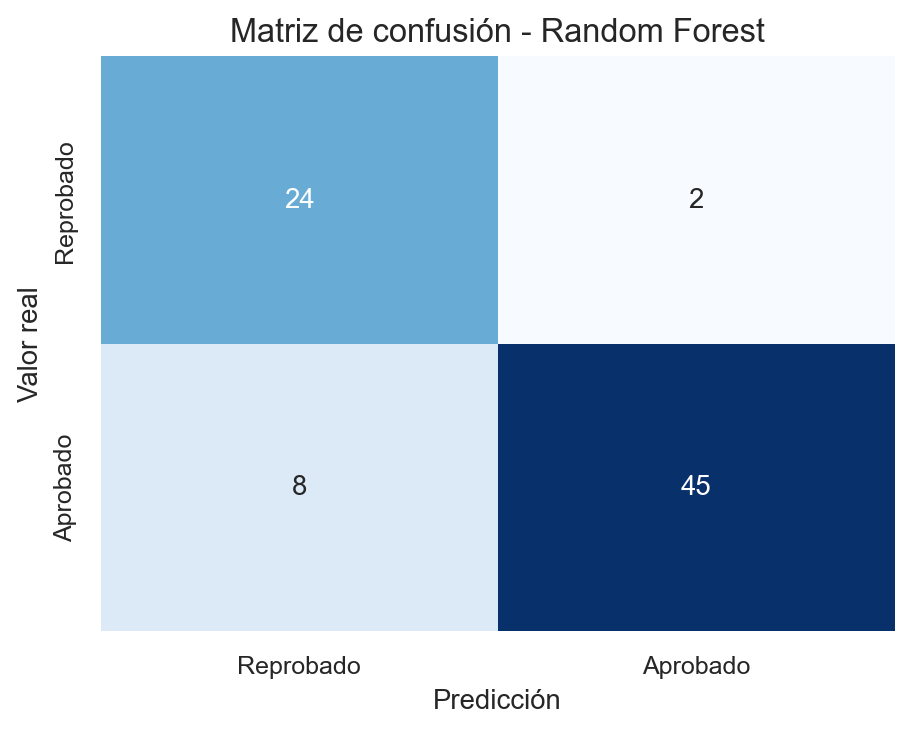


===== SVM =====
Accuracy: 0.8354
              precision    recall  f1-score   support

           0     0.7097    0.8462    0.7719        26
           1     0.9167    0.8302    0.8713        53

    accuracy                         0.8354        79
   macro avg     0.8132    0.8382    0.8216        79
weighted avg     0.8485    0.8354    0.8386        79



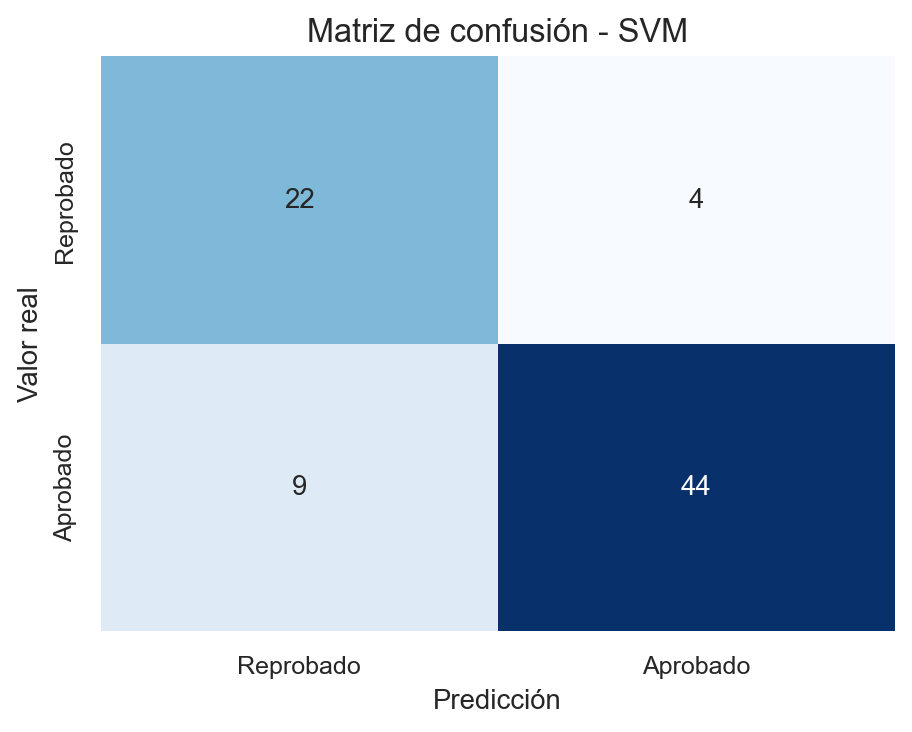

,Modelo,Accuracy
0,Random Forest,0.8734
1,SVM,0.8354


In [19]:
cls_models = {
    'Random Forest': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced'
        )),
    ]),
    'SVM': Pipeline([
        ('preprocess', preprocess_scaled),
        ('model', SVC(
            kernel='rbf',
            C=3,
            gamma='scale',
            class_weight='balanced',
            random_state=42,
        )),
    ]),
}

cls_results = []
cls_predictions = {}

for name, model in cls_models.items():
    model.fit(X_cls_train, y_cls_train)
    summary = classification_summary(name, model, X_cls_test, y_cls_test)
    cls_results.append({
        'Modelo': name,
        'Accuracy': summary['Accuracy'],
    })
    cls_predictions[name] = summary['Predicciones']
    print(f'\n===== {name} =====')
    print(f"Accuracy: {summary['Accuracy']:.4f}")
    print(summary['Reporte'])
    plot_confusion_matrix(y_cls_test, summary['Predicciones'], f'Matriz de confusión - {name}')

cls_results_df = pd.DataFrame(cls_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
cls_results_df

### Resultados de clasificación

Con la partición definida, los resultados observados fueron:

| Modelo | Accuracy | Matriz de confusión |
|---|---:|---|
| Random Forest | 0.8734 | $\begin{bmatrix}24 & 2\\ 8 & 45\end{bmatrix}$ |
| SVM | 0.8354 | $\begin{bmatrix}22 & 4\\ 9 & 44\end{bmatrix}$ |

### Interpretación técnica

- **Random Forest** logra el mejor desempeño global.
- El modelo SVM mantiene una capacidad competitiva, pero pierde algo de sensibilidad en la clase `Reprobado`.
- En ambos casos, la clase `Aprobado` domina el conjunto de prueba, por lo que la matriz de confusión es más útil que la accuracy sola para evaluar el comportamiento por clase.

## 6. Modelos de regresión

Aquí la meta es predecir la nota final `G3` como variable continua.

Se comparan:

- **Random Forest Regressor**: captura relaciones no lineales y efectos de interacción.
- **SVR**: versión regresiva de SVM, sensible a escalamiento y al ancho del margen de tolerancia.

Para regresión se reportan:

- $R^2$,
- MAE,
- RMSE.


===== Random Forest Regressor =====
R2:   0.8075
MAE:  1.1776
RMSE: 1.9868


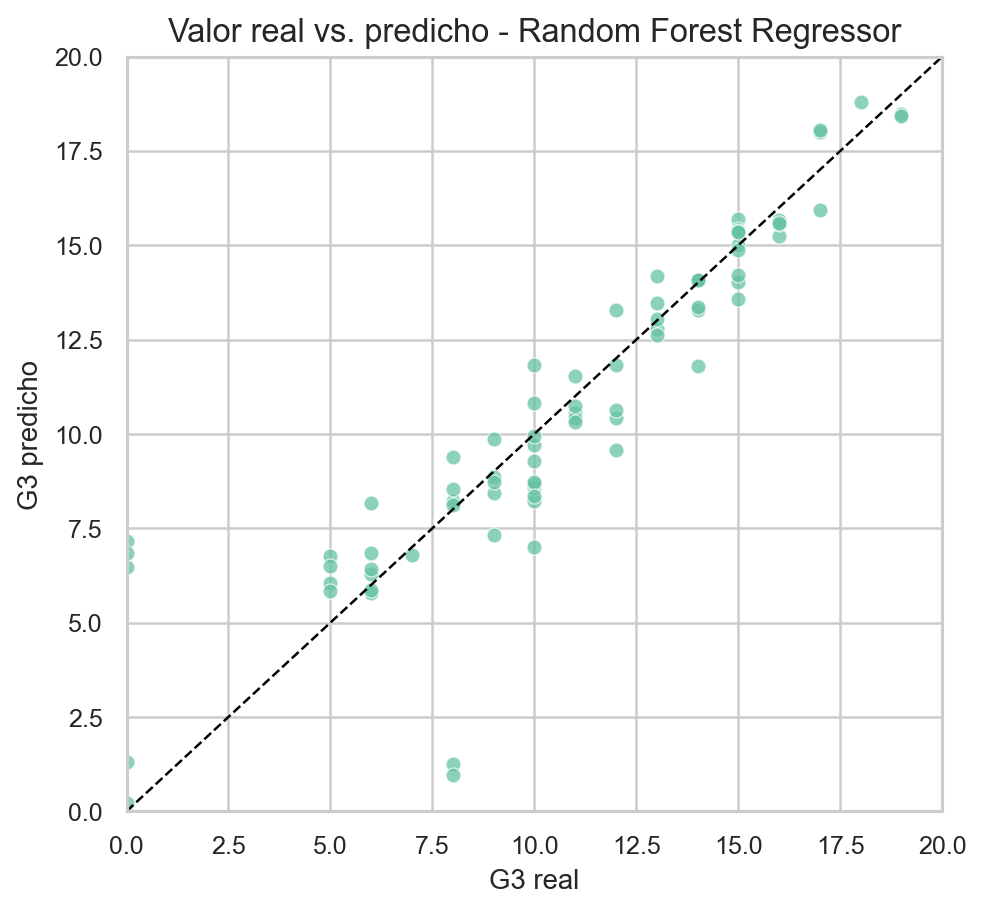


===== SVR =====
R2:   0.6797
MAE:  1.8580
RMSE: 2.5628


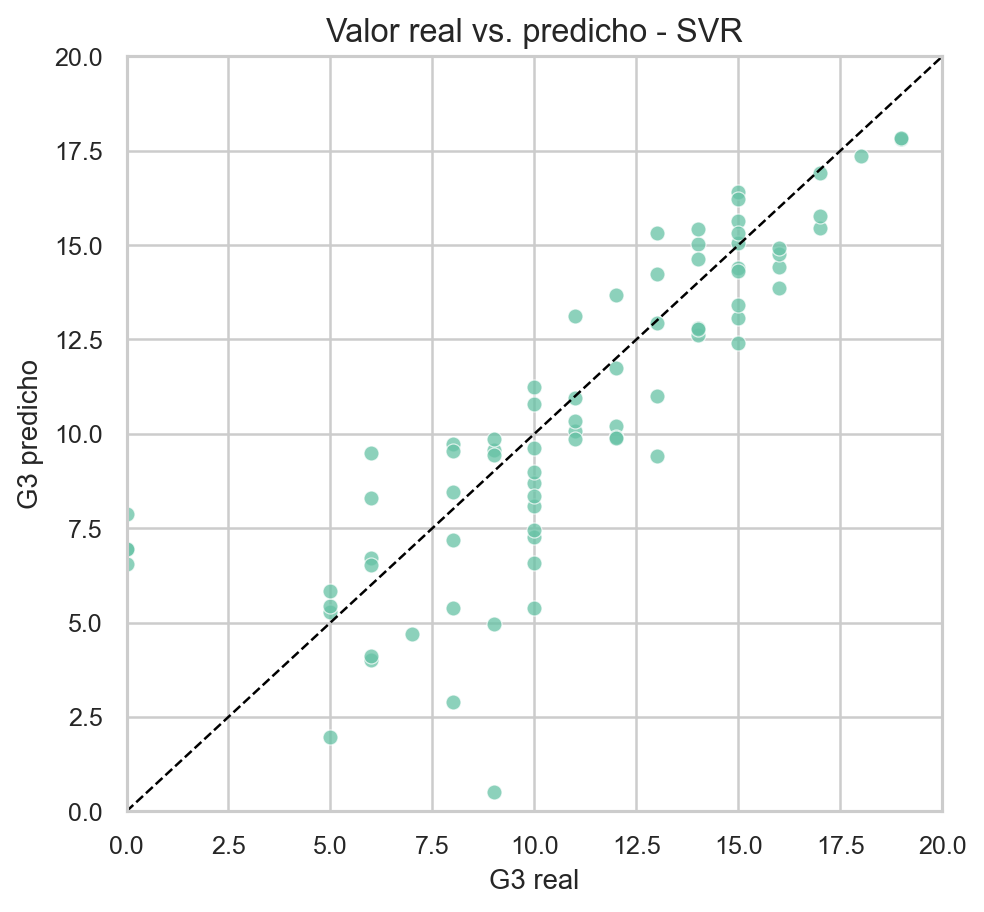

,Modelo,R2,MAE,RMSE
0,Random Forest Regressor,0.8075,1.1776,1.9868
1,SVR,0.6797,1.8580,2.5628


In [20]:
reg_models = {
    'Random Forest Regressor': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', RandomForestRegressor(
            n_estimators=400,
            random_state=42,
        )),
    ]),
    'SVR': Pipeline([
        ('preprocess', preprocess_scaled),
        ('model', SVR(
            kernel='rbf',
            C=30,
            epsilon=0.5,
            gamma='scale',
        )),
    ]),
}

reg_results = []
reg_predictions = {}

for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    pred = model.predict(X_reg_test)
    reg_predictions[name] = pred
    rmse = mean_squared_error(y_reg_test, pred) ** 0.5
    reg_results.append({
        'Modelo': name,
        'R2': r2_score(y_reg_test, pred),
        'MAE': mean_absolute_error(y_reg_test, pred),
        'RMSE': rmse,
    })
    print(f'\n===== {name} =====')
    print(f"R2:   {r2_score(y_reg_test, pred):.4f}")
    print(f"MAE:  {mean_absolute_error(y_reg_test, pred):.4f}")
    print(f"RMSE: {rmse:.4f}")

    plt.figure(figsize=(5.6, 5.2))
    sns.scatterplot(x=y_reg_test, y=pred, alpha=0.75)
    lims = [0, 20]
    plt.plot(lims, lims, '--', color='black', linewidth=1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.xlabel('G3 real')
    plt.ylabel('G3 predicho')
    plt.title(f'Valor real vs. predicho - {name}')
    plt.tight_layout()
    plt.show()

reg_results_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
reg_results_df

In [21]:
best_model = reg_models['Random Forest Regressor']

best_model.fit(X_reg_train, y_reg_train)

print("Modelo final entrenado correctamente")

Modelo final entrenado correctamente


### Resultados de regresión

Con la misma partición, los resultados obtenidos fueron:

| Modelo | $R^2$ | MAE | RMSE |
|---|---:|---:|---:|
| Random Forest Regressor | 0.8075 | 1.1776 | 1.9868 |
| SVR | 0.6797 | 1.8580 | 2.5628 |

### Interpretación técnica

- El **Random Forest Regressor** explica mejor la variabilidad de `G3`.
- El **SVR** sigue siendo útil, pero pierde precisión cuando la relación entre variables y nota final no es lineal.
- Un $R^2$ cercano a 0.81 significa que el modelo captura una parte sustancial del patrón del rendimiento final, aunque no todo, lo cual es razonable en un fenómeno educativo con alta variabilidad humana.

## 7. Comparación final y discusión de resultados

### Clasificación

- **Mejor modelo**: Random Forest.
- **Ventaja principal**: mayor accuracy y mejor equilibrio entre clases.
- **Lectura práctica**: predice mejor quién aprueba y quién reprueba, especialmente para la clase minoritaria `Reprobado`.

### Regresión

- **Mejor modelo**: Random Forest Regressor.
- **Ventaja principal**: mayor $R^2$ y menor error absoluto/cuadrático.
- **Lectura práctica**: aproxima mejor la nota final `G3` en escala 0-20.

### Conclusión ejecutiva

Si el objetivo es clasificar aprobación/reprobación, el modelo recomendado es **Random Forest Classifier**.
Si el objetivo es estimar la nota final esperada, el modelo recomendado es **Random Forest Regressor**.

Ambos resultados sugieren que el comportamiento académico en `student-mat.csv` presenta relaciones no lineales e interacciones complejas que los modelos de ensamble capturan mejor que los modelos de margen máximo en este caso.

In [22]:
print('=== Resumen de clasificación ===')
print(cls_results_df.to_string(index=False))
print('\n=== Resumen de regresión ===')
print(reg_results_df.to_string(index=False))

=== Resumen de clasificación ===
       Modelo  Accuracy
Random Forest    0.8734
          SVM    0.8354

=== Resumen de regresión ===
                 Modelo     R2    MAE   RMSE
Random Forest Regressor 0.8075 1.1776 1.9868
                    SVR 0.6797 1.8580 2.5628


In [23]:
import joblib

# Seleccionar el mejor modelo de regresión
best_model = reg_models['Random Forest Regressor']

# Entrenar nuevamente
best_model.fit(X_reg_train, y_reg_train)

# Guardar modelo
joblib.dump(best_model, 'modelo_g3.pkl')

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [27]:
import pandas as pd

df = pd.read_csv("student_clean.csv")

print(df.shape)
print(df.columns.tolist())

(395, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [35]:
import geopandas as gpd
import pandas as pd
import numpy as np

# Leer el GeoJSON de distritos
gdf = gpd.read_file("mapa_panama/panama_distritos.geojson")

# Crear un CSV base con los nombres de distritos
datos_distritos = pd.DataFrame({
    "distrito": gdf["shapeName"],
    "poblacion_estimada": np.random.randint(5000, 250000, size=len(gdf)),
    "indice_sociodemografico": np.random.uniform(40, 90, size=len(gdf)).round(2)
})

# Guardar el CSV
datos_distritos.to_csv("mapa_panama/datos_distritos.csv", index=False, encoding="utf-8")

print("Archivo datos_distritos.csv creado correctamente")
display(datos_distritos.head())
print("Cantidad de distritos:", len(datos_distritos))

Archivo datos_distritos.csv creado correctamente


c:\Users\CHVic\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'panama_distritos.geojson': 'geoBoundaries-PAN-ADM2' (default), 'geoBoundaries-PAN-ADM2_simplified'. Specify layer parameter to avoid this warning.
  result = read_func(


,distrito,poblacion_estimada,indice_sociodemografico
0,Changuinola,66290,79.6200
1,Bocas del Toro,158862,84.9900
2,ChiriquÃ­ Grande,238423,49.6300
3,Renacimiento,44689,86.4200
4,San FÃ©lix,238066,53.2500


Cantidad de distritos: 76


In [36]:
datos = pd.read_csv("mapa_panama/datos_distritos.csv")

print(datos.columns.tolist())
display(datos.head())
print(len(datos))

['distrito', 'poblacion_estimada', 'indice_sociodemografico']


,distrito,poblacion_estimada,indice_sociodemografico
0,Changuinola,66290,79.6200
1,Bocas del Toro,158862,84.9900
2,ChiriquÃ­ Grande,238423,49.6300
3,Renacimiento,44689,86.4200
4,San FÃ©lix,238066,53.2500


76
